# Chapter 13: Optimization and Curve Fitting

Companion notebook for *Python by Curiosity*. Every code listing from the chapter is
here, in the order it appears in the book, under the same title. Run the cells from
top to bottom: some listings use variables or functions defined in earlier cells.

The same listings are also available as separate scripts in `codes/listings/ch13_optimization/`.

In [ ]:
# Run the listings from the repository root so that paths such as
# data/grades.csv and figures/trophy.png work.
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working folder:", os.getcwd())

### Code 13.1: Gradient descent to minimize J(theta) = theta^2 - 4theta + 5

In [2]:
import numpy as np

# Cost function J(theta) and its derivative dJ/dtheta
def J(theta):
    return theta**2 - 4*theta + 5

def dJ(theta):
    return 2*theta - 4

# Gradient descent optimization
theta = 10.0      # Initial guess far from minimum
alpha = 0.1       # Learning rate
tolerance = 1e-6

for step in range(100):
    grad = dJ(theta)
    theta_new = theta - alpha * grad
    if abs(theta_new - theta) < tolerance:
        print(f"Converged in {step+1} steps!")
        break
    theta = theta_new

print(f"Optimal theta: {theta:.6f} (Exact minimum is theta = 2.0)")

Converged in 66 steps!
Optimal theta: 2.000004 (Exact minimum is theta = 2.0)


### Code 13.2: Gradient descent for linear regression

In [3]:
import numpy as np

rng = np.random.default_rng(0)
x_data = np.linspace(0, 10, 50)
y_data = 2.5 * x_data + 4.0 + rng.normal(0, 2, 50)

def gradient_descent(x, y, lr=0.01, epochs=1000):
    'Fit y = m*x + c to data by gradient descent.'
    n = len(x)
    m, c = 0.0, 0.0
    losses = []
    for _ in range(epochs):
        y_pred = m * x + c
        loss = np.mean((y - y_pred)**2)
        losses.append(loss)
        dm = -2 / n * np.sum(x * (y - y_pred))
        dc = -2 / n * np.sum(y - y_pred)
        m -= lr * dm
        c -= lr * dc
    return m, c, losses

m_fit, c_fit, losses = gradient_descent(x_data, y_data, lr=0.005, epochs=2000)
print(f'Fitted: y = {m_fit:.3f}x + {c_fit:.3f}')
print(f'True:   y = 2.500x + 4.000')

Fitted: y = 2.735x + 3.081
True:   y = 2.500x + 4.000


### Code 13.3: Effect of learning rate

/tmp/claude-1000/-home-aditya-draft-checks-Python-book-Python-Basics-Basics-book-working/be7e2298-56be-4b94-b358-016dc9538c1d/scratchpad/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_701379/1343675086.py:14: RuntimeWarning: overflow encountered in square
  loss = np.mean((y - y_pred)**2)
/tmp/claude-1000/-home-aditya-draft-checks-Python-book-Python-Basics-Basics-book-working/be7e2298-56be-4b94-b358-016dc9538c1d/scratchpad/venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_701379/1343675086.py:13: RuntimeWarning: invalid value encountered in multiply
  y_pred = m * x + c


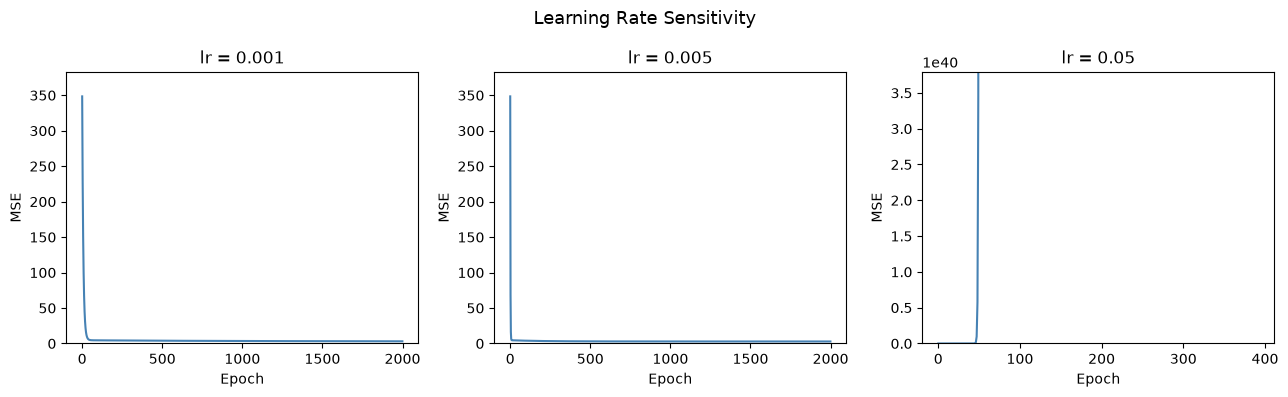

In [4]:
# Uses gradient_descent(), x_data and y_data from Code 13.2: run that first
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, lr in zip(axes, [0.001, 0.005, 0.05]):
    _, _, loss_curve = gradient_descent(x_data, y_data, lr=lr, epochs=2000)
    ax.plot(loss_curve, color='steelblue')
    ax.set_title(f'lr = {lr}')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
    ax.set_ylim(0, max(loss_curve[:50]) * 1.1)
fig.suptitle('Learning Rate Sensitivity', fontsize=13)
fig.tight_layout(); plt.show()

### Code 13.4: Normal equations for comparison

In [5]:
# Uses x_data and y_data from Code 13.2 (and its import of numpy as np)
# Build design matrix [1, x]
X = np.column_stack([np.ones_like(x_data), x_data])
w = np.linalg.solve(X.T @ X, X.T @ y_data)
print(f'Normal eqns: c={w[0]:.4f}, m={w[1]:.4f}')

Normal eqns: c=3.0977, m=2.7321


### Code 13.5: Fitting an exponential decay physics model

In [6]:
import numpy as np
from scipy.optimize import curve_fit

# Generate synthetic experimental data: y = A * exp(-b * x) + noise
np.random.seed(42)
x_exp = np.linspace(0, 5, 25)
y_true = 10.0 * np.exp(-0.8 * x_exp)
y_exp = y_true + np.random.normal(0, 0.4, size=len(x_exp))

# Define model function to fit
def exp_decay(x, A, b):
    return A * np.exp(-b * x)

# Fit parameters (A, b)
popt, pcov = curve_fit(exp_decay, x_exp, y_exp, p0=[5.0, 1.0])
A_fit, b_fit = popt

print(f"Fitted Amplitude A: {A_fit:.4f} (True A = 10.0)")
print(f"Fitted Decay Rate b: {b_fit:.4f} (True b = 0.8)")

Fitted Amplitude A: 10.3797 (True A = 10.0)
Fitted Decay Rate b: 0.8361 (True b = 0.8)


### Code 13.6: curve_fit and minimize

In [7]:
from scipy.optimize import curve_fit, minimize

# Uses x_data, y_data: the straight-line data from Code 13.2
# curve_fit: non-linear least squares
def model(x, m, c):
    return m * x + c

popt, pcov = curve_fit(model, x_data, y_data, p0=[1.0, 0.0])
print(f'curve_fit: m={popt[0]:.4f}, c={popt[1]:.4f}')
perr = np.sqrt(np.diag(pcov))
print(f'Uncertainties: dm={perr[0]:.4f}, dc={perr[1]:.4f}')

# minimize: general optimiser (Nelder-Mead, BFGS, etc.)
def mse(params):
    m, c = params
    return np.mean((y_data - (m * x_data + c))**2)

result = minimize(mse, x0=[0.0, 0.0], method='Nelder-Mead')
print(f'minimize: m={result.x[0]:.4f}, c={result.x[1]:.4f}')

curve_fit: m=2.7321, c=3.0977
Uncertainties: dm=0.0828, dc=0.4804
minimize: m=2.7321, c=3.0977


### Code 13.7: Revenue maximisation

Optimal price: Rs. 10.00
Max revenue:   Rs. 2,000


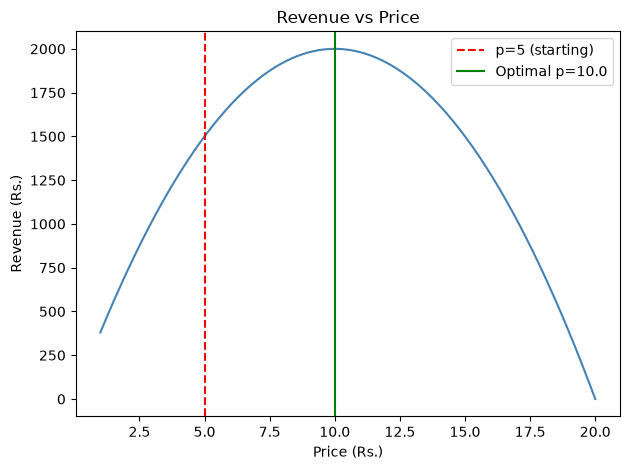

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Revenue R(p) = p * (200 - 20*(p-10)) = p*(400 - 20p)
def revenue(p):
    return p * (200 - 20 * (p - 10))

p_grid = np.linspace(1, 20, 300)
R_grid = revenue(p_grid)

fig, ax = plt.subplots()
ax.plot(p_grid, R_grid, color='steelblue')
ax.set_xlabel('Price (Rs.)'); ax.set_ylabel('Revenue (Rs.)')
ax.set_title('Revenue vs Price')
ax.axvline(5, color='red', linestyle='--', label='p=5 (starting)')

# scipy maximises by minimising negative revenue
from scipy.optimize import minimize_scalar
res = minimize_scalar(lambda p: -revenue(p), bounds=(1, 20), method='bounded')
print(f'Optimal price: Rs. {res.x:.2f}')
print(f'Max revenue:   Rs. {revenue(res.x):,.0f}')
ax.axvline(res.x, color='green', linestyle='-', label=f'Optimal p={res.x:.1f}')
ax.legend(); plt.tight_layout(); plt.show()

### Worked Example 13.1: 1D Gradient Descent Implementation

In [9]:
import numpy as np

# Target function and exact derivative
f = lambda x: x**4 - 3*x**3 + 2
df = lambda x: 4*x**3 - 9*x**2

x = 3.0           # Initial guess
alpha = 0.01      # Learning rate (step size multiplier)
tol = 1e-6

print(f"{'Step k':<7} | {'x_k':<10} | {'f(x_k)':<10} | {'df/dx':<10}")
print("-" * 44)

for k in range(1, 101):
    grad = df(x)
    fx = f(x)
    
    if k <= 5 or abs(grad) < tol:
        print(f"{k:<7} | {x:<10.6f} | {fx:<10.6f} | {grad:<10.4e}")
        
    if abs(grad) < tol:
        break
        
    x -= alpha * grad  # Gradient descent update rule

print(f"\nMinimum found at x = {x:.6f} with f(x) = {f(x):.6f} in {k} steps.")

# Output:
# Step k  | x_k        | f(x_k)     | df/dx     
# --------------------------------------------
# 1       | 3.000000   | 2.000000   | 2.7000e+01
# 2       | 2.730000   | -3.493533  | 1.4310e+01
# 3       | 2.586904   | -5.151411  | 9.0184e+00
# 4       | 2.496721   | -5.832834  | 6.1518e+00
# 5       | 2.435202   | -6.156391  | 4.3932e+00
# 72      | 2.250000   | -6.542969  | 8.0377e-07
# 
# Minimum found at x = 2.250000 with f(x) = -6.542969 in 72 steps.

Step k  | x_k        | f(x_k)     | df/dx     
--------------------------------------------
1       | 3.000000   | 2.000000   | 2.7000e+01
2       | 2.730000   | -3.493533  | 1.4310e+01
3       | 2.586904   | -5.151411  | 9.0184e+00
4       | 2.496721   | -5.832834  | 6.1518e+00
5       | 2.435202   | -6.156391  | 4.3932e+00
72      | 2.250000   | -6.542969  | 8.0377e-07

Minimum found at x = 2.250000 with f(x) = -6.542969 in 72 steps.


### Worked Example 13.2: Hooke's Law Linear Curve Fitting with np.polyfit

In [10]:
import numpy as np

# Experimental data
m = np.array([0.1, 0.2, 0.3, 0.4, 0.5])       # mass (kg)
x_cm = np.array([1.2, 2.5, 3.6, 4.9, 6.1])   # extension (cm)

g = 9.81
F_N = m * g                                  # Force (N)
x_m = x_cm / 100.0                           # Extension (m)

# Perform degree-1 linear fit: F = k * x + F0
k_stiffness, F0_bias = np.polyfit(x_m, F_N, 1)

# Calculate model predictions and residual norm
F_pred = k_stiffness * x_m + F0_bias
residual_rmse = np.sqrt(np.mean((F_N - F_pred)**2))

print(f"Spring Stiffness k:   {k_stiffness:.2f} N/m")
print(f"Zero-Load Bias F0:    {F0_bias:.4f} N")
print(f"Fit RMSE:             {residual_rmse:.4f} N")

# Output:
# Spring Stiffness k:   80.37 N/m
# Zero-Load Bias F0:    0.0016 N
# Fit RMSE:             0.0322 N

Spring Stiffness k:   80.37 N/m
Zero-Load Bias F0:    0.0016 N
Fit RMSE:             0.0322 N


### Worked Example 13.3: Exponential Decay Non-linear Fitting with curve_fit

In [11]:
import numpy as np
import scipy.optimize as opt

# Lab data
t_data = np.array([0, 2, 4, 6, 8, 10])
N_data = np.array([1000, 735, 540, 400, 290, 215])

# Non-linear model function
def decay_model(t, N0, lambda_decay):
    return N0 * np.exp(-lambda_decay * t)

# Perform non-linear least squares fit
initial_guess = [1000.0, 0.1]
popt, pcov = opt.curve_fit(decay_model, t_data, N_data, p0=initial_guess)

N0_fit, lambda_fit = popt
perr = np.sqrt(np.diag(pcov))  # Parameter 1-sigma standard errors

half_life = np.log(2) / lambda_fit

print(f"Fitted Initial Count N0: {N0_fit:.2f} +/- {perr[0]:.2f}")
print(f"Decay Constant lambda:   {lambda_fit:.4f} +/- {perr[1]:.4f} 1/hr")
print(f"Calculated Half-Life:    {half_life:.2f} hours")

# Output:
# Fitted Initial Count N0: 999.99 +/- 1.52
# Decay Constant lambda:   0.1538 +/- 0.0005 1/hr
# Calculated Half-Life:    4.51 hours

Fitted Initial Count N0: 999.99 +/- 1.52
Decay Constant lambda:   0.1538 +/- 0.0005 1/hr
Calculated Half-Life:    4.51 hours


### Worked Example 13.4: Constrained Cylindrical Tank Cost Optimization

In [12]:
import numpy as np
import scipy.optimize as opt

# Cost parameters
c_base = 500.0    # Rs / m^2
c_wall = 300.0    # Rs / m^2
V_target = 1.0    # Target volume (m^3)

# Objective cost function to minimize: x = [r, h]
def cost_function(x):
    r, h = x
    area_base = np.pi * (r**2)
    area_top_sides = np.pi * (r**2) + 2.0 * np.pi * r * h
    return c_base * area_base + c_wall * area_top_sides

# Constraint: Volume equality V = pi * r^2 * h = 1.0 -> (pi * r^2 * h - 1.0) = 0
volume_constraint = {'type': 'eq', 'fun': lambda x: np.pi * (x[0]**2) * x[1] - V_target}

# Positivity bounds: r > 0.05, h > 0.05
bounds = [(0.05, None), (0.05, None)]

# Initial guess: r = 0.5 m, h = 1.0 m
x0 = [0.5, 1.0]

# Solve constrained optimization problem
res = opt.minimize(cost_function, x0, method='SLSQP', bounds=bounds, constraints=volume_constraint)

r_opt, h_opt = res.x
min_cost = res.fun

print(f"Optimal Tank Radius r*: {r_opt:.4f} m")
print(f"Optimal Tank Height h*: {h_opt:.4f} m")
print(f"Height-to-Radius Ratio: {h_opt / r_opt:.2f}")
print(f"Minimum Production Cost: Rs. {min_cost:.2f}")

# Output:
# Optimal Tank Radius r*: 0.4924 m
# Optimal Tank Height h*: 1.3130 m
# Height-to-Radius Ratio: 2.67
# Minimum Production Cost: Rs. 1827.88

Optimal Tank Radius r*: 0.4924 m
Optimal Tank Height h*: 1.3130 m
Height-to-Radius Ratio: 2.67
Minimum Production Cost: Rs. 1827.88


### Real-World Solution

In [13]:
import numpy as np
from scipy.optimize import minimize_scalar

v1, v2 = 1.0, 1.0 / 1.333  # Light speeds in air and water

def transit_time(x):
    d1 = np.hypot(-2.0 - x, 1.5)
    d2 = np.hypot(1.5 - x, -1.5)
    return d1 / v1 + d2 / v2

res = minimize_scalar(transit_time, bounds=(-2.0, 1.5), method='bounded')
x_opt = res.x

# Verify Snell's Law: sin(theta1)/v1 == sin(theta2)/v2
sin_th1 = abs(-2.0 - x_opt) / np.hypot(-2.0 - x_opt, 1.5)
sin_th2 = abs(1.5 - x_opt) / np.hypot(1.5 - x_opt, -1.5)

print(f"Optimal interface crossing point: x* = {x_opt:.4f}")
print(f"Air Snell ratio   (sin theta1 / v1): {sin_th1 / v1:.4f}")
print(f"Water Snell ratio (sin theta2 / v2): {sin_th2 / v2:.4f}")

# Output:
# Optimal interface crossing point: x* = 0.2908
# Air Snell ratio   (sin theta1 / v1): 0.8366
# Water Snell ratio (sin theta2 / v2): 0.8366

Optimal interface crossing point: x* = 0.2908
Air Snell ratio   (sin theta1 / v1): 0.8366
Water Snell ratio (sin theta2 / v2): 0.8366
